### Behavioural Health Informatics Project

In [1]:
#Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import warnings 
warnings.simplefilter(action='ignore', category=FutureWarning)

### Loading and checking the data

In [2]:
#read the csv-file
data = pd.read_csv('alzheimers_disease_data.csv', sep = ',')

#form the dataframe
df = pd.DataFrame(data)

# Convert categorical data to appropriate types
df['Ethnicity'] = df['Ethnicity'].astype('category')
df['Gender'] = df['Gender'].astype('category')
df['Smoking'] = df['Smoking'].astype('category')

df.describe()

,PatientID,Age,EducationLevel,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,1.286645,27.655697,10.039442,4.920202,4.993138,7.051081,0.252210,0.144253,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.904527,7.217438,5.757910,2.857191,2.909055,1.763573,0.434382,0.351428,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,15.008851,0.002003,0.003616,0.009385,4.002629,0.000000,0.000000,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,1.000000,21.611408,5.139810,2.570626,2.458455,5.482997,0.000000,0.000000,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,27.823924,9.934412,4.766424,5.076087,7.115646,0.000000,0.000000,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,2.000000,33.869778,15.157931,7.427899,7.558625,8.562521,1.000000,0.000000,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,3.000000,39.992767,19.989293,9.987429,9.998346,9.999840,1.000000,1.000000,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Checking if the data set has any missing values:

In [3]:
print(df.isna().sum())

PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

Constructing the dataframe, and getting the basic summary statistics with pandas.

In [4]:
#construct a new data frame with only the studied columns
df = df[['Age', 'Gender', 'Ethnicity', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'Diagnosis']]

df.describe()

,Age,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,74.908795,27.655697,10.039442,4.920202,4.993138,7.051081,0.353653
std,8.990221,7.217438,5.757910,2.857191,2.909055,1.763573,0.478214
min,60.000000,15.008851,0.002003,0.003616,0.009385,4.002629,0.000000
25%,67.000000,21.611408,5.139810,2.570626,2.458455,5.482997,0.000000
50%,75.000000,27.823924,9.934412,4.766424,5.076087,7.115646,0.000000
75%,83.000000,33.869778,15.157931,7.427899,7.558625,8.562521,1.000000
max,90.000000,39.992767,19.989293,9.987429,9.998346,9.999840,1.000000


### Overall impact of lifestyle factors across ethnic groups

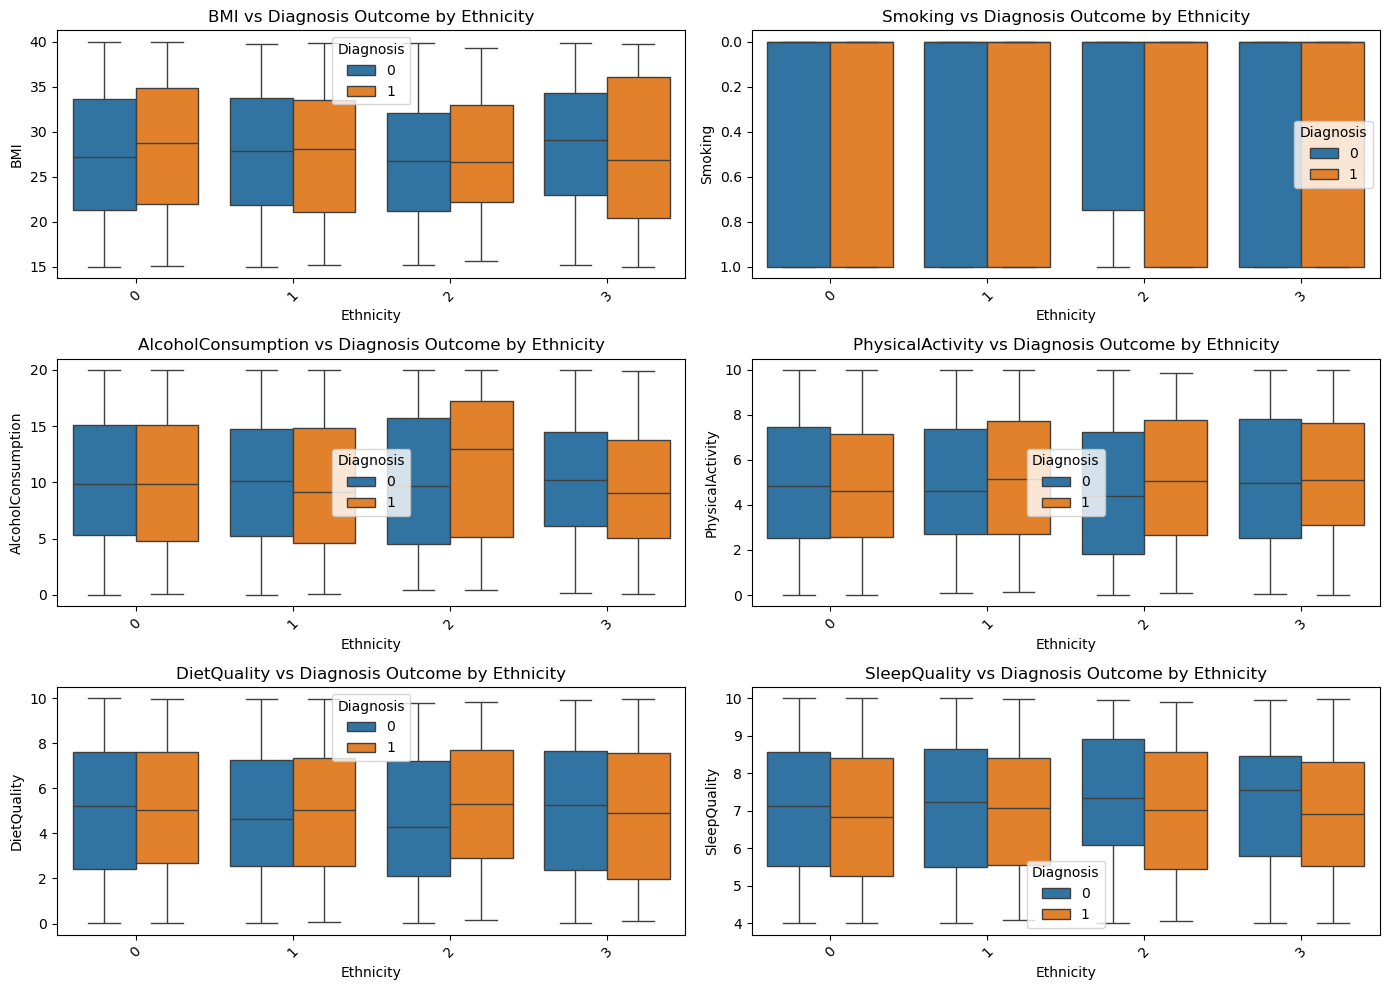

In [5]:
lifestyle_factors = ['BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality']
outcome = 'Diagnosis'

plt.figure(figsize=(14, 10))
for i, factor in enumerate(lifestyle_factors, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x = 'Ethnicity', y = factor, hue = 'Diagnosis', data=df)
    plt.title(f"{factor} vs Diagnosis Outcome by Ethnicity")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Checking correlations inside each ethnic group

**Caucasian**

In [12]:
# Find the values where ethnicity corresponds to correct numerical category
print('Caucasian')
df_caucasian = df.loc[df['Ethnicity'] == 0]
print(df_caucasian)
print(df_caucasian.shape)

Caucasian
      Age Gender Ethnicity        BMI Smoking  AlcoholConsumption  \
0      73      0         0  22.927749       0           13.297218   
1      89      0         0  26.827681       0            4.542524   
3      74      1         0  33.800817       1           12.209266   
4      89      0         0  20.716974       0           18.454356   
7      75      0         0  18.776009       0           13.723826   
...   ...    ...       ...        ...     ...                 ...   
2142   88      0         0  20.097600       0            4.089458   
2144   61      0         0  39.121757       0            1.561126   
2145   75      0         0  17.857903       0           18.767261   
2146   77      0         0  15.476479       0            4.594670   
2148   72      0         0  33.289738       0            7.890703   

      PhysicalActivity  DietQuality  SleepQuality  Diagnosis  
0             6.327112     1.347214      9.025679          0  
1             7.619885     0.518767

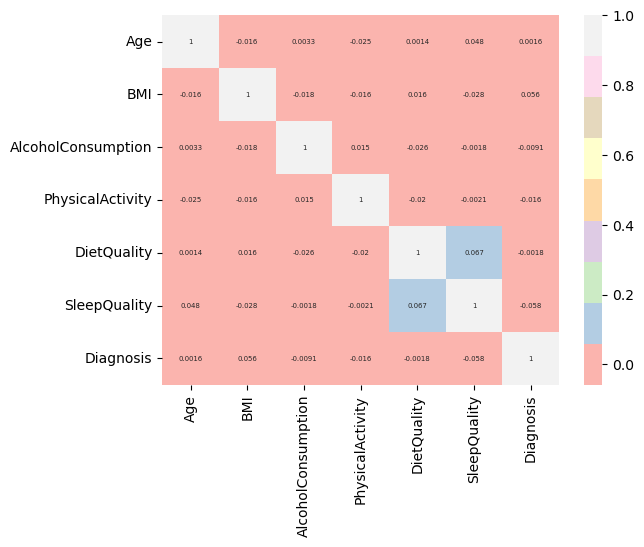

In [13]:
dataplot = sns.heatmap(df_caucasian.corr(numeric_only = True), cmap = 'Pastel1', annot = True, annot_kws={"size": 5})
plt.show()

**African American**

In [14]:
# Find the values where ethnicity corresponds to correct numerical category
print('African American')
df_aa = df.loc[df['Ethnicity'] == 1]
print(df_aa)
print(df_aa.shape)

African American
      Age Gender Ethnicity        BMI Smoking  AlcoholConsumption  \
5      86      1         1  30.626886       0            4.140144   
8      72      1         1  27.833188       0           12.167848   
16     63      1         1  22.822896       1            4.433961   
21     65      0         1  37.543943       1           12.063959   
25     77      0         1  39.123677       0            0.953869   
...   ...    ...       ...        ...     ...                 ...   
2126   75      1         1  35.832125       0           13.036673   
2129   75      1         1  36.569773       0            0.592078   
2131   79      1         1  16.760487       0            5.097337   
2139   68      0         1  17.828965       0            2.982747   
2140   89      0         1  34.422419       0            7.770687   

      PhysicalActivity  DietQuality  SleepQuality  Diagnosis  
5             0.211062     1.584922      7.261953          0  
8             1.531360     6

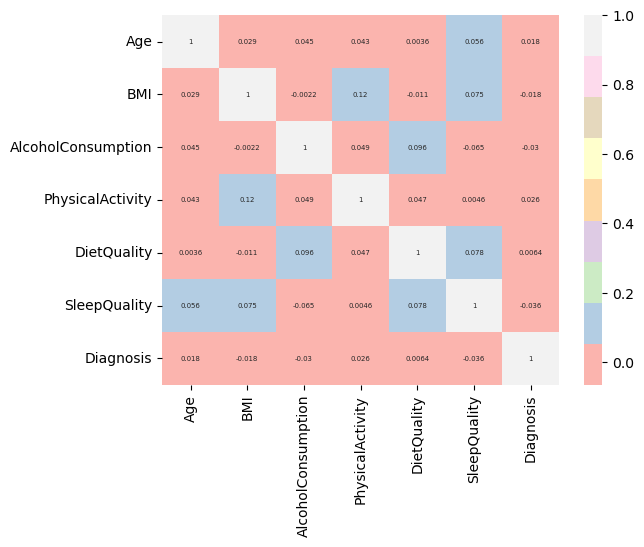

In [15]:
dataplot = sns.heatmap(df_aa.corr(numeric_only = True), cmap = 'Pastel1', annot = True, annot_kws={"size": 5})
plt.show()

**Asian**

In [16]:
# Find the values where ethnicity corresponds to correct numerical category
print('Asian')
df_asian = df.loc[df['Ethnicity'] == 2]
print(df_asian)
print(df_asian.shape)

Asian
      Age Gender Ethnicity        BMI Smoking  AlcoholConsumption  \
23     82      1         2  21.969390       0            3.289650   
50     81      0         2  15.639677       0           15.649190   
53     61      1         2  38.076135       0           19.984018   
67     63      1         2  22.049002       0           13.220110   
77     90      1         2  21.288593       0            3.375024   
...   ...    ...       ...        ...     ...                 ...   
2125   70      1         2  35.592158       1           17.105628   
2127   89      1         2  35.806100       1           13.076450   
2130   81      1         2  22.630945       1            2.328341   
2136   83      1         2  19.006926       0           13.980834   
2143   66      1         2  32.013806       1            9.308706   

      PhysicalActivity  DietQuality  SleepQuality  Diagnosis  
23            6.934726     3.242343      4.412596          1  
50            6.848293     0.161403    

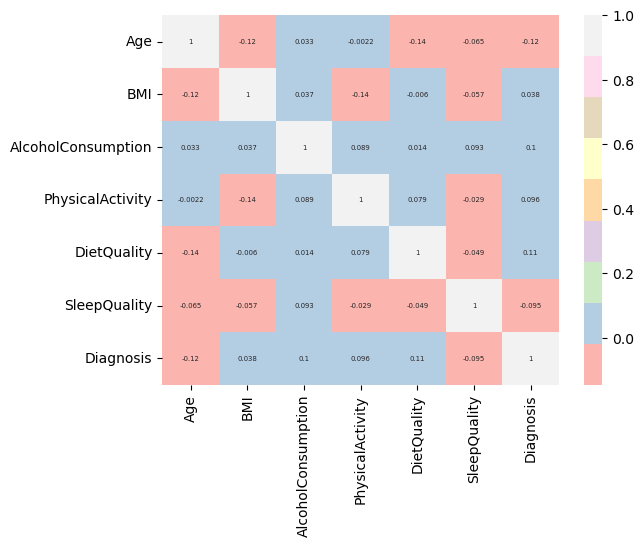

In [17]:
dataplot = sns.heatmap(df_asian.corr(numeric_only = True), cmap = 'Pastel1', annot = True, annot_kws={"size": 5})
plt.show()

**Other**

In [18]:
# Find the values where ethnicity corresponds to correct numerical category
print('Other')
df_other = df.loc[df['Ethnicity'] == 3]
print(df_other)
print(df_other.shape)

Other
      Age Gender Ethnicity        BMI Smoking  AlcoholConsumption  \
2      73      0         3  17.795882       0           19.555085   
6      68      0         3  38.387622       1            0.646047   
10     89      0         3  39.463034       0            9.811292   
31     67      0         3  37.205177       0           12.215677   
47     69      1         3  16.480199       1           17.947653   
...   ...    ...       ...        ...     ...                 ...   
2099   79      1         3  30.921927       1           17.597034   
2102   62      1         3  26.062347       0            6.131512   
2105   83      0         3  31.095664       0            7.542266   
2137   86      0         3  24.226040       0           10.890948   
2147   78      1         3  15.299911       0            8.674505   

      PhysicalActivity  DietQuality  SleepQuality  Diagnosis  
2             7.844988     1.826335      9.673574          0  
6             9.257695     5.897388    

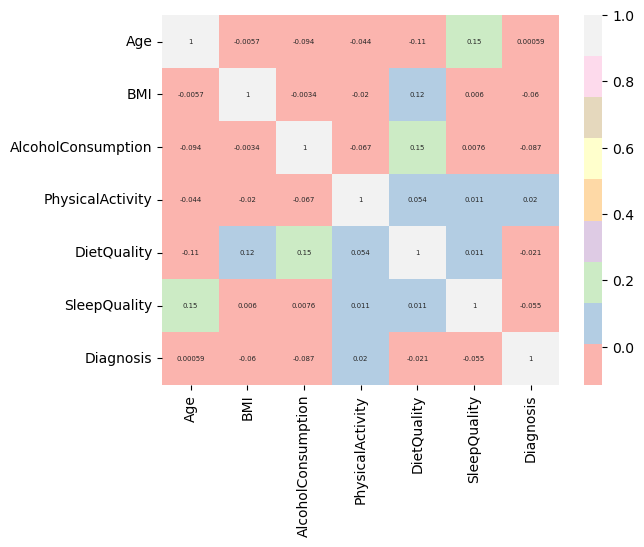

In [19]:
dataplot = sns.heatmap(df_other.corr(numeric_only = True), cmap = 'Pastel1', annot = True, annot_kws={"size": 5})
plt.show()

**All ethnic groups**

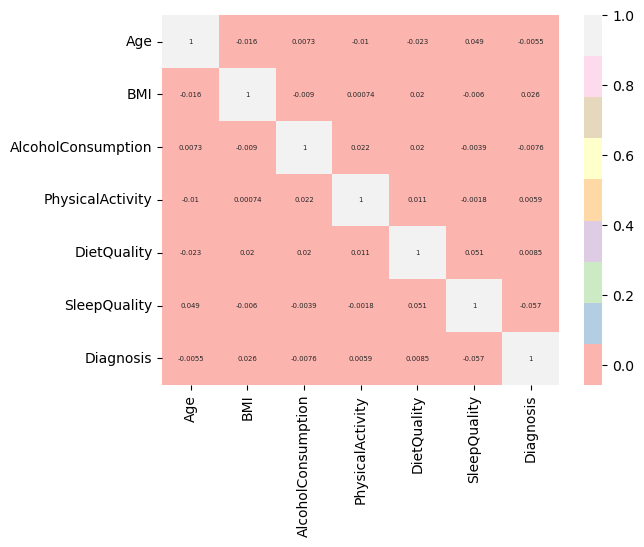

In [20]:
dataplot = sns.heatmap(df.corr(numeric_only = True), cmap = 'Pastel1', annot = True, annot_kws={"size": 5})
plt.show()

Checking the gender distribution of diagnosis outcomes, across all ethnic groups.

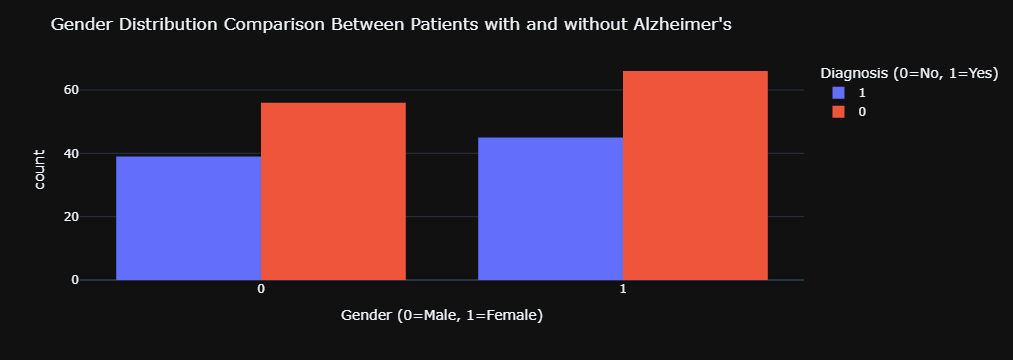

In [21]:
import plotly.express as px
fig = px.histogram(df_asian, x='Gender', color='Diagnosis', barmode='group', labels={'Gender':'Gender (0=Male, 1=Female)',
                                                                                 'Diagnosis':'Diagnosis (0=No, 1=Yes)'}, 
                   template="plotly_dark")
fig.update_layout(title="Gender Distribution Comparison Between Patients with and without Alzheimer's")
fig.show()

### Constructing the new data

Based on EDA outcome, only certain features were chosen for further investigation.

In [22]:
#construct a new data frame with only the studied columns
df = df[['Ethnicity', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'Diagnosis']]
features = ['Ethnicity', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality']

Constructing new dataframes for each ethnic group with the new features

**Caucasian**

In [23]:
# Find the values where ethnicity corresponds to correct numerical category
print('Caucasian')
df_caucasian = df.loc[df['Ethnicity'] == 0]
print(df_caucasian)
print(df_caucasian.shape)

Caucasian
     Ethnicity Smoking  AlcoholConsumption  PhysicalActivity  DietQuality  \
0            0       0           13.297218          6.327112     1.347214   
1            0       0            4.542524          7.619885     0.518767   
3            0       1           12.209266          8.428001     7.435604   
4            0       0           18.454356          6.310461     0.795498   
7            0       0           13.723826          4.649451     8.341903   
...        ...     ...                 ...               ...          ...   
2142         0       0            4.089458          7.389633     2.878738   
2144         0       0            1.561126          4.049964     6.555306   
2145         0       0           18.767261          1.360667     2.904662   
2146         0       0            4.594670          9.886002     8.120025   
2148         0       0            7.890703          6.570993     7.941404   

      SleepQuality  Diagnosis  
0         9.025679          0  
1

**African American**

In [24]:
# Find the values where ethnicity corresponds to correct numerical category
print('African American')
df_aa = df.loc[df['Ethnicity'] == 1]
print(df_aa)
print(df_aa.shape)

African American
     Ethnicity Smoking  AlcoholConsumption  PhysicalActivity  DietQuality  \
5            1       0            4.140144          0.211062     1.584922   
8            1       0           12.167848          1.531360     6.736882   
16           1       1            4.433961          7.182895     7.929486   
21           1       1           12.063959          9.126038     3.531207   
25           1       0            0.953869          8.939249     0.043147   
...        ...     ...                 ...               ...          ...   
2126         1       0           13.036673          2.604905     4.278960   
2129         1       0            0.592078          5.289253     7.543583   
2131         1       0            5.097337          0.565122     7.367998   
2139         1       0            2.982747          8.394826     0.317526   
2140         1       0            7.770687          0.947567     5.732139   

      SleepQuality  Diagnosis  
5         7.261953        

**Asian**

In [25]:
# Find the values where ethnicity corresponds to correct numerical category
print('Asian')
df_asian = df.loc[df['Ethnicity'] == 2]
print(df_asian)
print(df_asian.shape)

Asian
     Ethnicity Smoking  AlcoholConsumption  PhysicalActivity  DietQuality  \
23           2       0            3.289650          6.934726     3.242343   
50           2       0           15.649190          6.848293     0.161403   
53           2       0           19.984018          9.859542     1.915171   
67           2       0           13.220110          8.731341     5.426497   
77           2       0            3.375024          9.277794     2.613100   
...        ...     ...                 ...               ...          ...   
2125         2       1           17.105628          4.548318     1.264489   
2127         2       1           13.076450          6.523344     8.591301   
2130         2       1            2.328341          0.334605     4.103678   
2136         2       0           13.980834          8.150727     8.369827   
2143         2       1            9.308706          4.352402     5.432374   

      SleepQuality  Diagnosis  
23        4.412596          1  
50   

**Other**

In [26]:
# Find the values where ethnicity corresponds to correct numerical category
print('Other')
df_other = df.loc[df['Ethnicity'] == 3]
print(df_other)
print(df_other.shape)

Other
     Ethnicity Smoking  AlcoholConsumption  PhysicalActivity  DietQuality  \
2            3       0           19.555085          7.844988     1.826335   
6            3       1            0.646047          9.257695     5.897388   
10           3       0            9.811292          8.819950     0.434020   
31           3       0           12.215677          7.780544     6.433890   
47           3       1           17.947653          0.307674     8.951570   
...        ...     ...                 ...               ...          ...   
2099         3       1           17.597034          1.109198     5.776591   
2102         3       0            6.131512          7.044546     1.218132   
2105         3       0            7.542266          4.593094     7.603504   
2137         3       0           10.890948          2.938590     5.530857   
2147         3       0            8.674505          6.354282     1.263427   

      SleepQuality  Diagnosis  
2         9.673574          0  
6    

### ANOVA

Dependent variables:
- Ethnicity
- Smoking
- Alcohol consumption
- Diet quality
- Sleep quality
- Physical activity

Independent variable: Diagnosis

In [54]:
anova_results = {}

continuous_vars = ["AlcoholConsumption", "DietQuality", "SleepQuality", "PhysicalActivity"]
categorical_vars = ["Smoking", "Ethnicity"]

for var in continuous_vars:
    anova_results[var] = stats.f_oneway(df[var], df["Diagnosis"])
    
for var in categorical_vars:
    groups = [df[df[var] == level]["Diagnosis"] for level in df[var].unique()]
    anova_results[var] = stats.f_oneway(*groups)

# Display results
for var, result in anova_results.items():
    print(f"ANOVA for {var}: F={result.statistic:.4f}, p-value={result.pvalue:.4f}")

ANOVA for AlcoholConsumption: F=6039.3639, p-value=0.0000
ANOVA for DietQuality: F=5322.2067, p-value=0.0000
ANOVA for SleepQuality: F=28870.3426, p-value=0.0000
ANOVA for PhysicalActivity: F=5339.9272, p-value=0.0000
ANOVA for Smoking: F=0.0508, p-value=0.8217
ANOVA for Ethnicity: F=2.1030, p-value=0.0978


### Decision trees

In this section, decision trees for each ethnic group were made. Each decision tree was statistically analysed.

In [30]:
# Importing necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.tree import plot_tree

**All Ethnicities**

In [31]:
X = df.drop('Diagnosis',axis=1)
y = df['Diagnosis'].copy()

df_train_all, df_test_all, outcome_train_all, outcome_test_all = train_test_split(X, y, test_size = 0.3, random_state = 42)
#stratify = y


print(df_train_all.shape)
print(df_test_all.shape)

train_count = outcome_train_all.value_counts()
test_count = outcome_test_all.value_counts()
print(train_count)
print(test_count)

(1504, 6)
(645, 6)
Diagnosis
0    988
1    516
Name: count, dtype: int64
Diagnosis
0    401
1    244
Name: count, dtype: int64


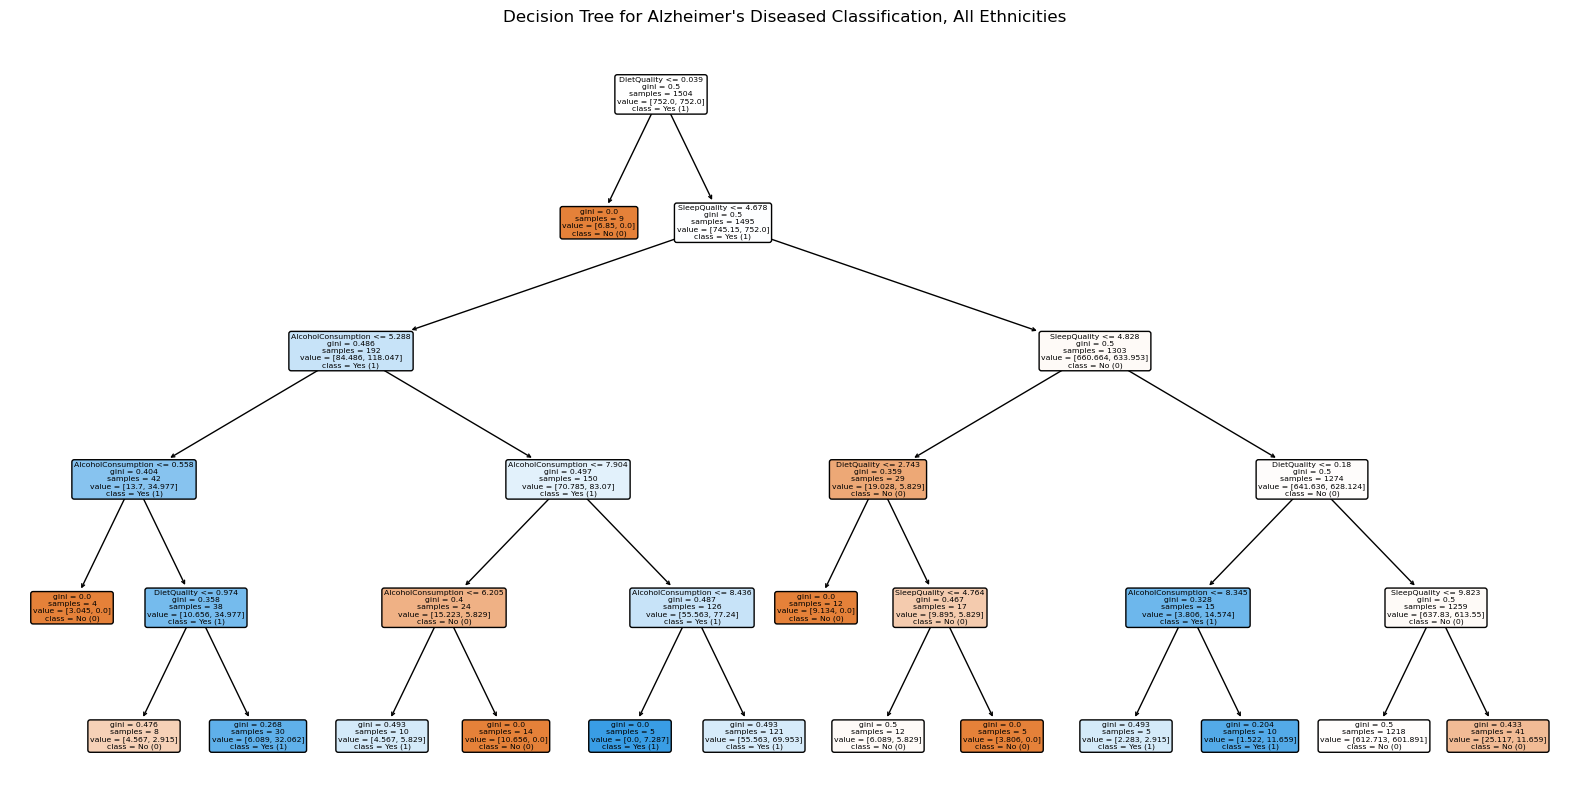

Accuracy: 0.6
Precision: 0.4027777777777778
Sensitivity: 0.11885245901639344


In [32]:
# define the parameters

max_depth = 5
min_samples_split = 8
min_samples_leaf = 3

# form the classifier
dt_clf_all = DecisionTreeClassifier(max_depth=max_depth,
                                min_samples_split = min_samples_split,
                                min_samples_leaf = min_samples_leaf,
                                class_weight="balanced",
                                random_state=42)

# train the tree for training data set
dt_clf_all.fit(df_train_all, outcome_train_all)

# Predict on the test set
outcome_pred_dt_all = dt_clf_all.predict(df_test_all)

#Plot the tree
plt.figure(figsize=(20, 10))
decision_tree_all = plot_tree(dt_clf_all, feature_names = X.columns, class_names=["No (0)", "Yes (1)"], filled=True, rounded=True)
plt.title("Decision Tree for Alzheimer's Diseased Classification, All Ethnicities")
plt.show()

# Calculate metrics
accuracy_all = accuracy_score(outcome_test_all, outcome_pred_dt_all)
precision_all = precision_score(outcome_test_all, outcome_pred_dt_all)
sensitivity_all = recall_score(outcome_test_all, outcome_pred_dt_all) 

print('Accuracy:',accuracy_all)
print('Precision:',precision_all)
print('Sensitivity:',sensitivity_all)

**Caucasian**

In [33]:
X = df_caucasian.drop('Diagnosis',axis=1)
y = df_caucasian['Diagnosis'].copy()

df_train_caucasian, df_test_caucasian, outcome_train_caucasian, outcome_test_caucasian = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)


print(df_train_caucasian.shape)
print(df_test_caucasian.shape)

train_count = outcome_train_caucasian.value_counts()
test_count = outcome_test_caucasian.value_counts()
print(train_count)
print(test_count)

(894, 6)
(384, 6)
Diagnosis
0    570
1    324
Name: count, dtype: int64
Diagnosis
0    245
1    139
Name: count, dtype: int64


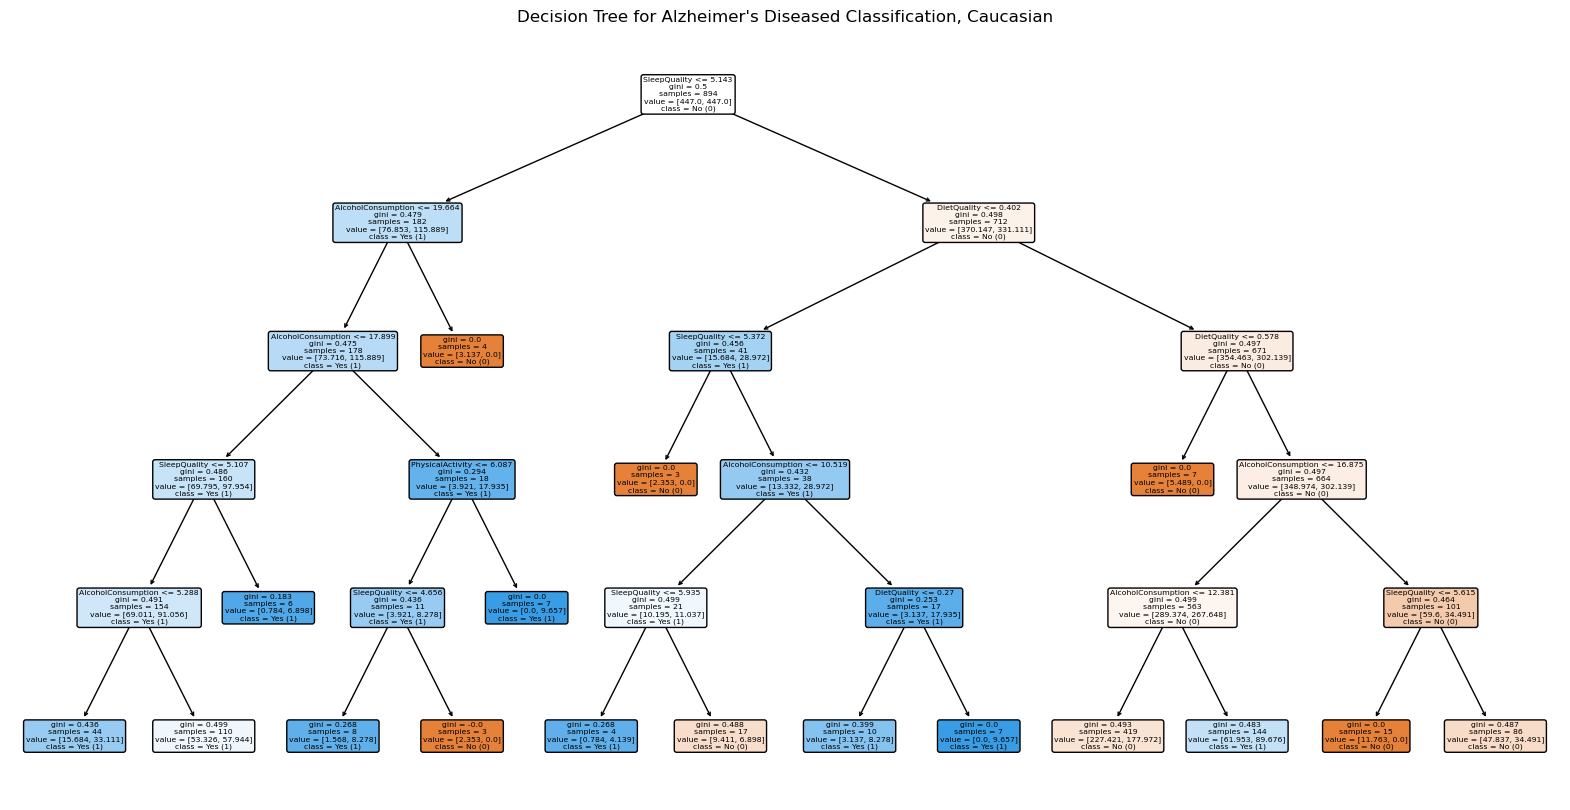

Accuracy: 0.515625
Precision: 0.3333333333333333
Sensitivity: 0.3381294964028777


In [34]:
# define the parameters

max_depth = 5
min_samples_split = 8
min_samples_leaf = 3

# form the classifier
dt_clf_caucasian = DecisionTreeClassifier(max_depth=max_depth,
                                min_samples_split = min_samples_split,
                                min_samples_leaf = min_samples_leaf,
                                class_weight="balanced",
                                random_state=42)

# train the tree for training data set
dt_clf_caucasian.fit(df_train_caucasian, outcome_train_caucasian)

# Predict on the test set
outcome_pred_dt_caucasian = dt_clf_caucasian.predict(df_test_caucasian)

#Plot the tree
plt.figure(figsize=(20, 10))
decision_tree_caucasian = plot_tree(dt_clf_caucasian, feature_names = X.columns, class_names=["No (0)", "Yes (1)"], filled=True, rounded=True)
plt.title("Decision Tree for Alzheimer's Diseased Classification, Caucasian")
plt.show()

# Calculate metrics
accuracy_caucasian = accuracy_score(outcome_test_caucasian, outcome_pred_dt_caucasian)
precision_caucasian = precision_score(outcome_test_caucasian, outcome_pred_dt_caucasian)
sensitivity_caucasian = recall_score(outcome_test_caucasian, outcome_pred_dt_caucasian) 

print('Accuracy:',accuracy_caucasian)
print('Precision:',precision_caucasian)
print('Sensitivity:',sensitivity_caucasian)

**African American**

In [35]:
X = df_aa.drop('Diagnosis',axis=1)
y = df_aa['Diagnosis'].copy()

df_train_aa, df_test_aa, outcome_train_aa, outcome_test_aa = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

print(df_train_aa.shape)
print(df_test_aa.shape)

train_count = outcome_train_aa.value_counts()
test_count = outcome_test_aa.value_counts()
print(train_count)
print(test_count)

(317, 6)
(137, 6)
Diagnosis
0    215
1    102
Name: count, dtype: int64
Diagnosis
0    93
1    44
Name: count, dtype: int64


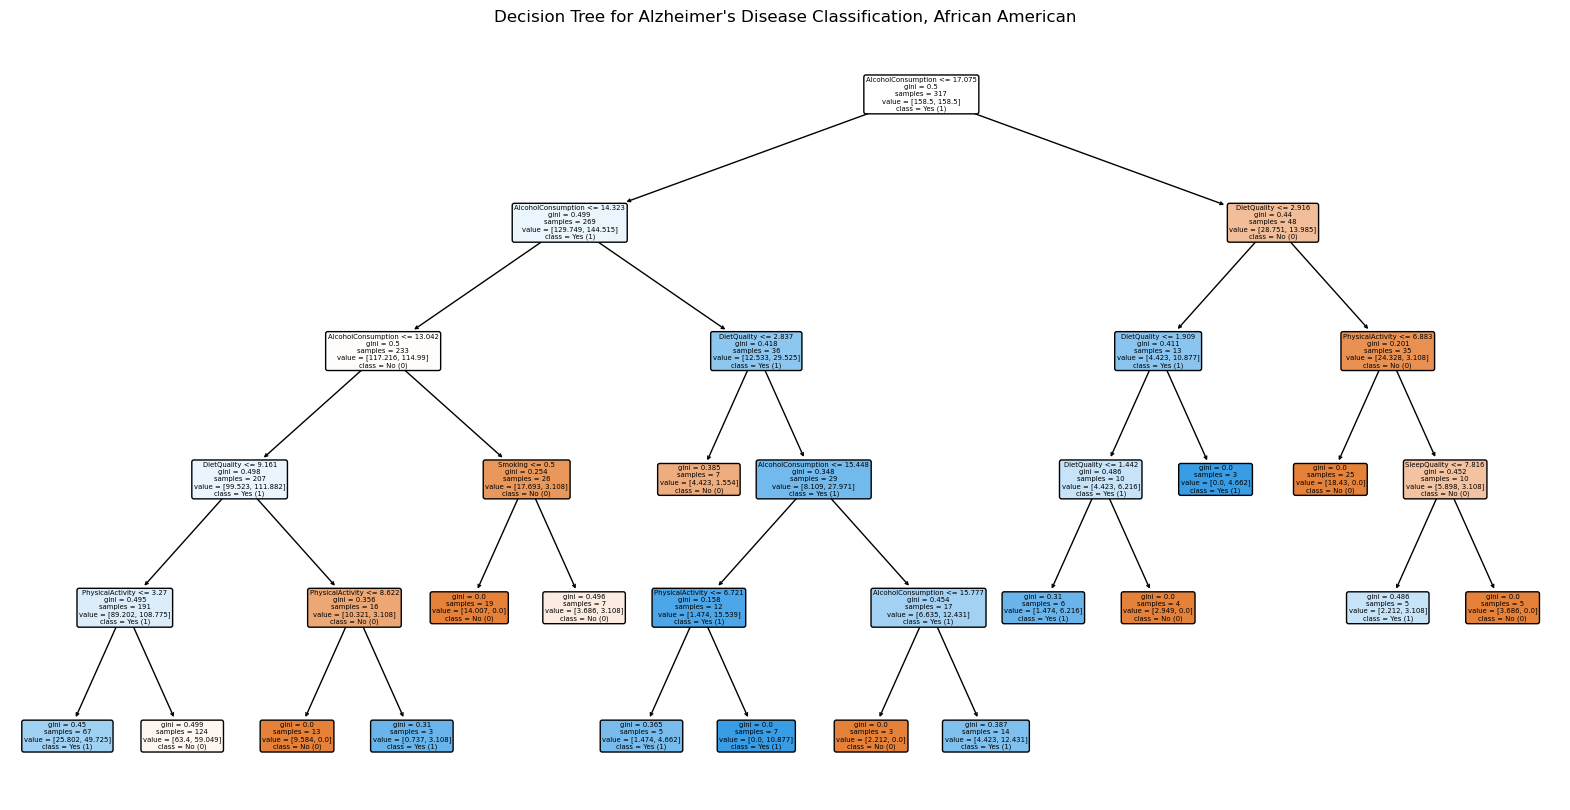

Accuracy: 0.5255474452554745
Precision: 0.2857142857142857
Sensitivity: 0.3181818181818182


In [36]:
# define the parameters

max_depth = 5
min_samples_split = 8
min_samples_leaf = 3

# form the classifier
dt_clf_aa = DecisionTreeClassifier(max_depth=max_depth,
                                min_samples_split = min_samples_split,
                                min_samples_leaf = min_samples_leaf,
                                class_weight="balanced",
                                random_state=42)

# train the tree for training data set
dt_clf_aa.fit(df_train_aa, outcome_train_aa)

# Predict on the test set
outcome_pred_dt_aa = dt_clf_aa.predict(df_test_aa)

#Plot the tree
plt.figure(figsize=(20, 10))
decision_tree_aa = plot_tree(dt_clf_aa, feature_names = X.columns, class_names=["No (0)", "Yes (1)"], filled=True, rounded=True)
plt.title("Decision Tree for Alzheimer's Disease Classification, African American")
plt.show()

# Calculate metrics
accuracy_aa = accuracy_score(outcome_test_aa, outcome_pred_dt_aa)
precision_aa = precision_score(outcome_test_aa, outcome_pred_dt_aa)
sensitivity_aa = recall_score(outcome_test_aa, outcome_pred_dt_aa) 

print('Accuracy:',accuracy_aa)
print('Precision:',precision_aa)
print('Sensitivity:',sensitivity_aa)

**Asian**

In [37]:
X = df_asian.drop('Diagnosis',axis=1)
y = df_asian['Diagnosis'].copy()

df_train_asian, df_test_asian, outcome_train_asian, outcome_test_asian = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

print(df_train_asian.shape)
print(df_test_asian.shape)

train_count = outcome_train_asian.value_counts()
test_count = outcome_test_asian.value_counts()
print(train_count)
print(test_count)

(144, 6)
(62, 6)
Diagnosis
0    85
1    59
Name: count, dtype: int64
Diagnosis
0    37
1    25
Name: count, dtype: int64


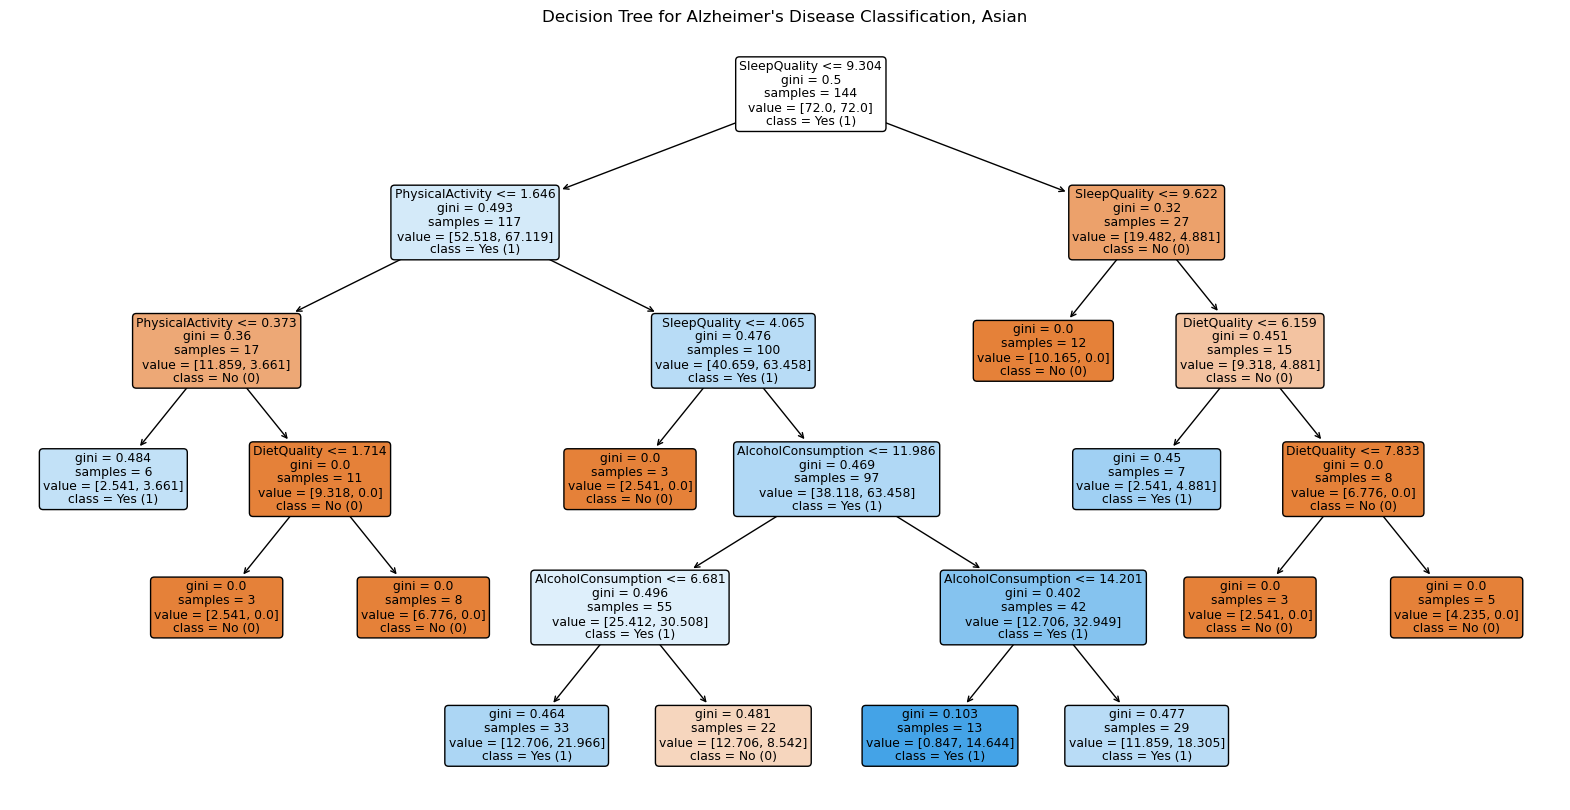

Accuracy: 0.5806451612903226
Precision: 0.4883720930232558
Sensitivity: 0.84


In [38]:
# define the parameters

max_depth = 5
min_samples_split = 8
min_samples_leaf = 3

# form the classifier
dt_clf_asian = DecisionTreeClassifier(max_depth=max_depth,
                                min_samples_split = min_samples_split,
                                min_samples_leaf = min_samples_leaf,
                                class_weight="balanced",
                                random_state=42)

# train the tree for training data set
dt_clf_asian.fit(df_train_asian, outcome_train_asian)

# Predict on the test set
outcome_pred_dt_asian = dt_clf_asian.predict(df_test_asian)

#Plot the tree
plt.figure(figsize=(20, 10))
decision_tree_asian = plot_tree(dt_clf_asian, feature_names = X.columns, class_names=["No (0)", "Yes (1)"], filled=True, rounded=True)
plt.title("Decision Tree for Alzheimer's Disease Classification, Asian")
plt.show()

# Calculate metrics
accuracy_asian = accuracy_score(outcome_test_asian, outcome_pred_dt_asian)
precision_asian = precision_score(outcome_test_asian, outcome_pred_dt_asian)
sensitivity_asian = recall_score(outcome_test_asian, outcome_pred_dt_asian) 

print('Accuracy:',accuracy_asian)
print('Precision:',precision_asian)
print('Sensitivity:',sensitivity_asian)

**Other**

In [39]:
X = df_other.drop('Diagnosis',axis=1)
y = df_other['Diagnosis'].copy()

df_train_other, df_test_other, outcome_train_other, outcome_test_other = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

print(df_train_other.shape)
print(df_test_other.shape)

train_count = outcome_train_other.value_counts()
test_count = outcome_test_other.value_counts()
print(train_count)
print(test_count)

(147, 6)
(64, 6)
Diagnosis
0    100
1     47
Name: count, dtype: int64
Diagnosis
0    44
1    20
Name: count, dtype: int64


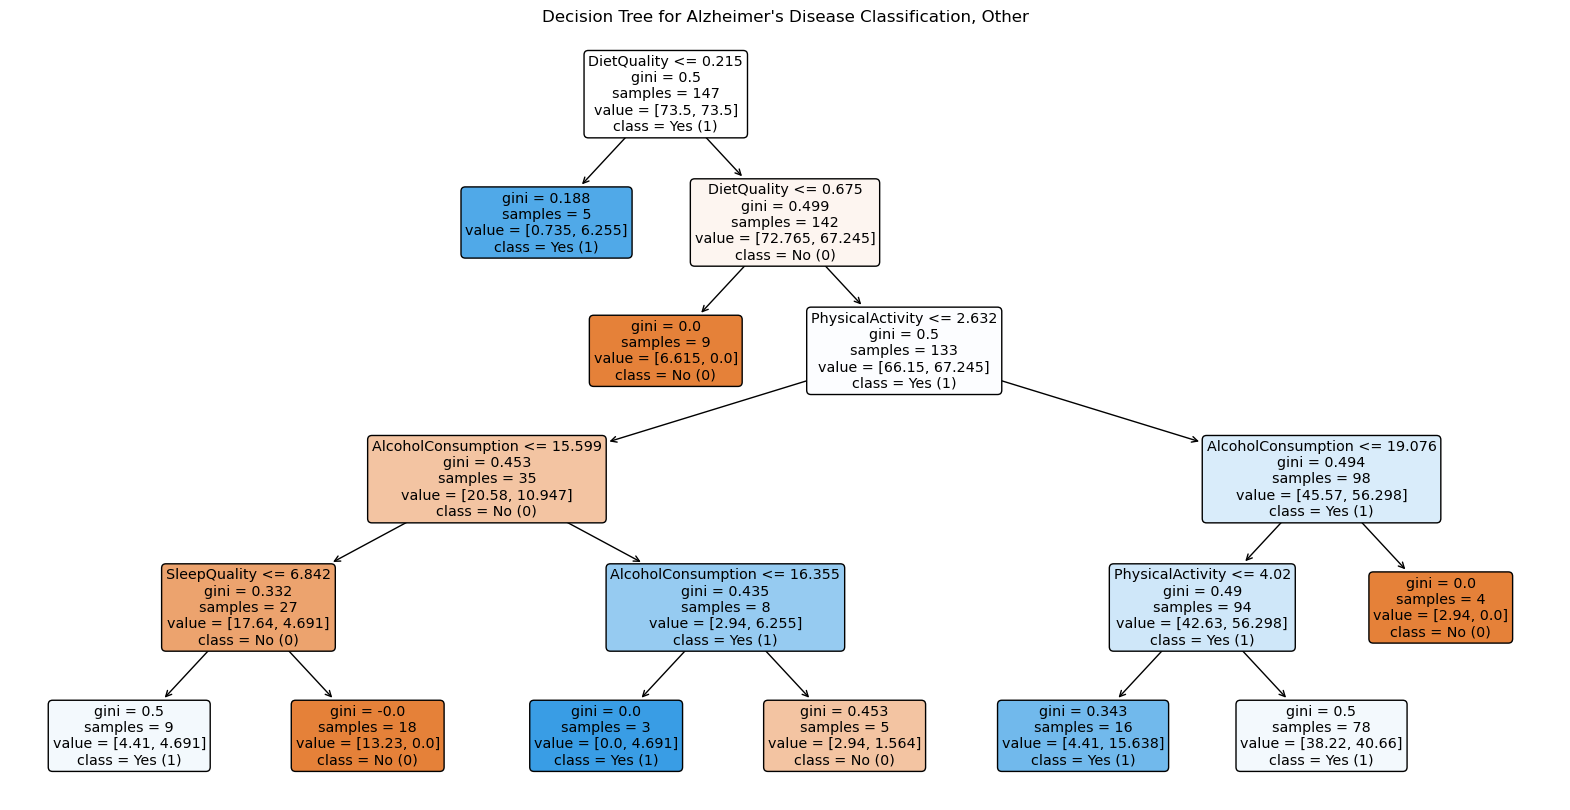

Accuracy: 0.390625
Precision: 0.32727272727272727
Sensitivity: 0.9


In [40]:
# define the parameters

max_depth = 5
min_samples_split = 8
min_samples_leaf = 3

# form the classifier
dt_clf_other = DecisionTreeClassifier(max_depth=max_depth,
                                min_samples_split = min_samples_split,
                                min_samples_leaf = min_samples_leaf,
                                class_weight="balanced",
                                random_state=42)

# train the tree for training data set
dt_clf_other.fit(df_train_other, outcome_train_other)

# Predict on the test set
outcome_pred_dt_other = dt_clf_other.predict(df_test_other)

#Plot the tree
plt.figure(figsize=(20, 10))
decision_tree_other = plot_tree(dt_clf_other, feature_names = X.columns, class_names=["No (0)", "Yes (1)"], filled=True, rounded=True)
plt.title("Decision Tree for Alzheimer's Disease Classification, Other")
plt.show()

# Calculate metrics
accuracy_other = accuracy_score(outcome_test_other, outcome_pred_dt_other)
precision_other = precision_score(outcome_test_other, outcome_pred_dt_other)
sensitivity_other = recall_score(outcome_test_other, outcome_pred_dt_other) 

print('Accuracy:',accuracy_other)
print('Precision:',precision_other)
print('Sensitivity:',sensitivity_other)

### Logistic regression

In this section, logistic regression classifier was made for each ethnic group. Each classifier was statistically analysed.

In [41]:
#Importing necessary libraries
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score

**All Ethnicities**

In [42]:
X = df.drop('Diagnosis',axis=1)
y = df['Diagnosis'].copy()

df_train_all, df_test_all, outcome_train_all, outcome_test_all = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

print(df_train_all.shape)
print(df_test_all.shape)

train_count = outcome_train_all.value_counts()
test_count = outcome_test_all.value_counts()

clf_logreg_all = LogisticRegression(class_weight = 'balanced', random_state = 42)
std_scaler = StandardScaler()
clf_pipe_all = Pipeline([('scaler', std_scaler), ('clf', clf_logreg_all)])
clf_pipe_all.fit(df_train_all, np.ravel(outcome_train_all))

outcome_pred_logreg_all = clf_pipe_all.predict(df_test_all)

(1504, 6)
(645, 6)


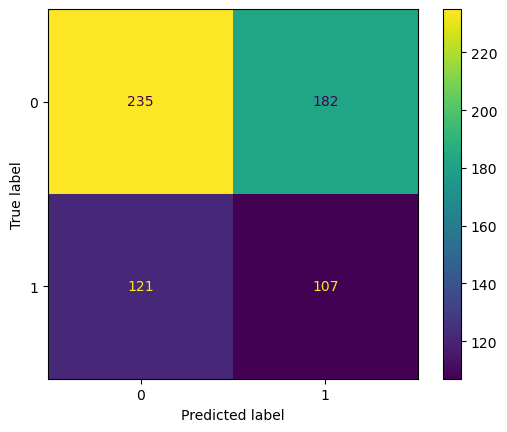

Prediction accuracy can be evaluated by:
Accuracy score:  0.5302325581395348 
Recall score: 0.4692982456140351 
Precision score: 0.370242214532872


In [43]:
matrix_logreg_all = confusion_matrix(outcome_test_all, outcome_pred_logreg_all)
display_all = ConfusionMatrixDisplay(confusion_matrix = matrix_logreg_all, display_labels = clf_pipe_all.named_steps['clf'].classes_)
display_all.plot()
plt.show()

#Accuracy interpretation

accuracy_logreg_all = accuracy_score(outcome_test_all, outcome_pred_logreg_all)
recall_logreg_all = recall_score(outcome_test_all, outcome_pred_logreg_all)
precision_logreg_all = precision_score(outcome_test_all, outcome_pred_logreg_all)

print('Prediction accuracy can be evaluated by:\nAccuracy score: ', accuracy_logreg_all, 
      '\nRecall score:', recall_logreg_all,'\nPrecision score:', precision_logreg_all) 

**Caucasian**

In [44]:
X = df_caucasian.drop('Diagnosis',axis=1)
y = df_caucasian['Diagnosis'].copy()

df_train_caucasian, df_test_caucasian, outcome_train_caucasian, outcome_test_caucasian = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

print(df_train_caucasian.shape)
print(df_test_caucasian.shape)

train_count = outcome_train_caucasian.value_counts()
test_count = outcome_test_caucasian.value_counts()

clf_logreg_caucasian = LogisticRegression(class_weight = 'balanced', random_state = 42)
std_scaler = StandardScaler()
clf_pipe_caucasian = Pipeline([('scaler', std_scaler), ('clf', clf_logreg_caucasian)])
clf_pipe_caucasian.fit(df_train_caucasian, np.ravel(outcome_train_caucasian))

outcome_pred_logreg_caucasian = clf_pipe_caucasian.predict(df_test_caucasian)

(894, 6)
(384, 6)


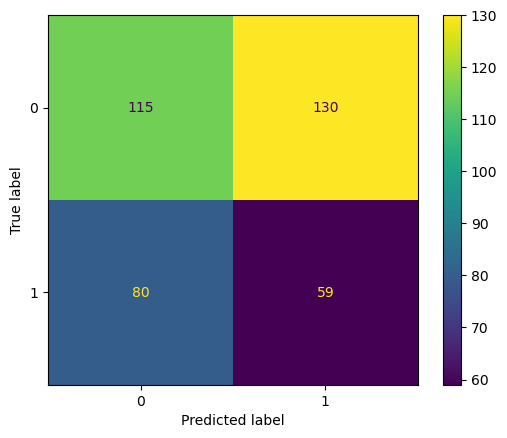

Prediction accuracy can be evaluated by:
Accuracy score:  0.453125 
Recall score: 0.4244604316546763 
Precision score: 0.31216931216931215


In [45]:
matrix_logreg_caucasian = confusion_matrix(outcome_test_caucasian, outcome_pred_logreg_caucasian)
display_caucasian = ConfusionMatrixDisplay(confusion_matrix = matrix_logreg_caucasian, display_labels = clf_pipe_caucasian.named_steps['clf'].classes_)
display_caucasian.plot()
plt.show()

#Accuracy interpretation

accuracy_logreg_caucasian = accuracy_score(outcome_test_caucasian, outcome_pred_logreg_caucasian)
recall_logreg_caucasian = recall_score(outcome_test_caucasian, outcome_pred_logreg_caucasian)
precision_logreg_caucasian = precision_score(outcome_test_caucasian, outcome_pred_logreg_caucasian)

print('Prediction accuracy can be evaluated by:\nAccuracy score: ', accuracy_logreg_caucasian, 
      '\nRecall score:', recall_logreg_caucasian,'\nPrecision score:', precision_logreg_caucasian) 

**African American**

In [46]:
X = df_aa.drop('Diagnosis',axis=1)
y = df_aa['Diagnosis'].copy()

df_train_aa, df_test_aa, outcome_train_aa, outcome_test_aa = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

print(df_train_aa.shape)
print(df_test_aa.shape)

train_count = outcome_train_aa.value_counts()
test_count = outcome_test_aa.value_counts()

clf_logreg_aa = LogisticRegression(class_weight = 'balanced', random_state = 42)
std_scaler = StandardScaler()
clf_pipe_aa = Pipeline([('scaler', std_scaler), ('clf', clf_logreg_aa)])
clf_pipe_aa.fit(df_train_aa, np.ravel(outcome_train_aa))

outcome_pred_logreg_aa = clf_pipe_aa.predict(df_test_aa)

(317, 6)
(137, 6)


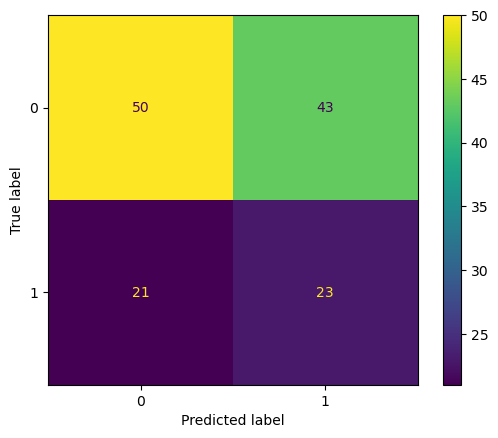

Prediction accuracy can be evaluated by:
Accuracy score:  0.5328467153284672 
Recall score: 0.5227272727272727 
Precision score: 0.3484848484848485


In [47]:
matrix_logreg_aa = confusion_matrix(outcome_test_aa, outcome_pred_logreg_aa)
display_aa = ConfusionMatrixDisplay(confusion_matrix = matrix_logreg_aa, display_labels = clf_pipe_aa.named_steps['clf'].classes_)
display_aa.plot()
plt.show()

#Accuracy interpretation

accuracy_logreg_aa = accuracy_score(outcome_test_aa, outcome_pred_logreg_aa)
recall_logreg_aa = recall_score(outcome_test_aa, outcome_pred_logreg_aa)
precision_logreg_aa = precision_score(outcome_test_aa, outcome_pred_logreg_aa)

print('Prediction accuracy can be evaluated by:\nAccuracy score: ', accuracy_logreg_aa, 
      '\nRecall score:', recall_logreg_aa,'\nPrecision score:', precision_logreg_aa) 

**Asian**

In [48]:
X = df_asian.drop('Diagnosis',axis=1)
y = df_asian['Diagnosis'].copy()

df_train_asian, df_test_asian, outcome_train_asian, outcome_test_asian = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

print(df_train_asian.shape)
print(df_test_asian.shape)

train_count = outcome_train_asian.value_counts()
test_count = outcome_test_asian.value_counts()

clf_logreg_asian = LogisticRegression(class_weight = 'balanced', random_state = 42)
std_scaler = StandardScaler()
clf_pipe_asian = Pipeline([('scaler', std_scaler), ('clf', clf_logreg_asian)])
clf_pipe_asian.fit(df_train_asian, np.ravel(outcome_train_asian))

outcome_pred_logreg_asian = clf_pipe_asian.predict(df_test_asian)

(144, 6)
(62, 6)


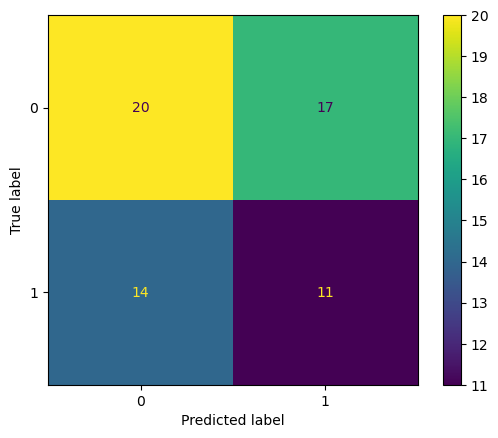

Prediction accuracy can be evaluated by:
Accuracy score:  0.5 
Recall score: 0.44 
Precision score: 0.39285714285714285


In [49]:
matrix_logreg_asian = confusion_matrix(outcome_test_asian, outcome_pred_logreg_asian)
display_asian = ConfusionMatrixDisplay(confusion_matrix = matrix_logreg_asian, display_labels = clf_pipe_asian.named_steps['clf'].classes_)
display_asian.plot()
plt.show()

#Accuracy interpretation

accuracy_logreg_asian = accuracy_score(outcome_test_asian, outcome_pred_logreg_asian)
recall_logreg_asian = recall_score(outcome_test_asian, outcome_pred_logreg_asian)
precision_logreg_asian = precision_score(outcome_test_asian, outcome_pred_logreg_asian)

print('Prediction accuracy can be evaluated by:\nAccuracy score: ', accuracy_logreg_asian, 
      '\nRecall score:', recall_logreg_asian,'\nPrecision score:', precision_logreg_asian) 

**Other**

In [50]:
X = df_other.drop('Diagnosis',axis=1)
y = df_other['Diagnosis'].copy()

df_train_other, df_test_other, outcome_train_other, outcome_test_other = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)

print(df_train_other.shape)
print(df_test_other.shape)

train_count = outcome_train_other.value_counts()
test_count = outcome_test_other.value_counts()

clf_logreg_other = LogisticRegression(class_weight = 'balanced', random_state = 42)
std_scaler = StandardScaler()
clf_pipe_other = Pipeline([('scaler', std_scaler), ('clf', clf_logreg_other)])
clf_pipe_other.fit(df_train_other, np.ravel(outcome_train_other))

outcome_pred_logreg_other = clf_pipe_other.predict(df_test_other)

(147, 6)
(64, 6)


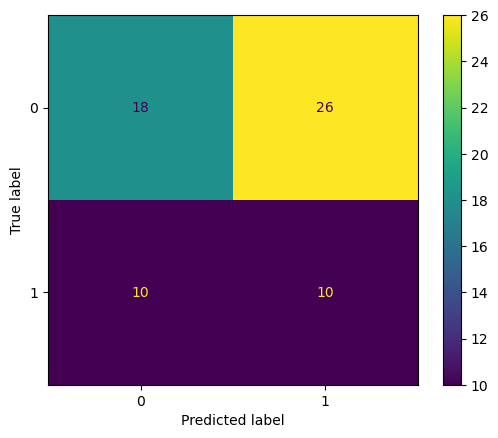

Prediction accuracy can be evaluated by:
Accuracy score:  0.4375 
Recall score: 0.5 
Precision score: 0.2777777777777778


In [51]:
matrix_logreg_other = confusion_matrix(outcome_test_other, outcome_pred_logreg_other)
display_other = ConfusionMatrixDisplay(confusion_matrix = matrix_logreg_other, display_labels = clf_pipe_other.named_steps['clf'].classes_)
display_other.plot()
plt.show()

#Accuracy interpretation

accuracy_logreg_other = accuracy_score(outcome_test_other, outcome_pred_logreg_other)
recall_logreg_other = recall_score(outcome_test_other, outcome_pred_logreg_other)
precision_logreg_other = precision_score(outcome_test_other, outcome_pred_logreg_other)

print('Prediction accuracy can be evaluated by:\nAccuracy score: ', accuracy_logreg_other, 
      '\nRecall score:', recall_logreg_other,'\nPrecision score:', precision_logreg_other) 